# Linux Kernel — Analiza pogłębiona

## A. Odporność sieci na ataki  
## B. Meta-graf subsystemów

Kontynuacja analizy z notebooka 01. Wymagane zmienne są tutaj ładowane od nowa z CSV.

In [1]:
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkit as nk

DATA = Path("../data/out")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

# Wczytaj dane
print("Wczytuję dane...")
metrics = pd.read_csv(DATA / "node_metrics.csv")
subsys  = pd.read_csv(DATA / "subsystem_stats.csv")
edges   = pd.read_csv(DATA / "edges.csv")

# Dołącz subsystem do krawędzi
node_sub = metrics[["id", "subsystem"]].set_index("id")
edges = edges.join(node_sub.rename(columns={"subsystem": "src_sys"}), on="source")
edges = edges.join(node_sub.rename(columns={"subsystem": "tgt_sys"}), on="target")

# Buduj graf NetworKit (nieskierowany)
print("Buduję graf NetworKit...")
all_nodes = metrics["id"].tolist()
node2id   = {n: i for i, n in enumerate(all_nodes)}
id2node   = {i: n for n, i in node2id.items()}
n_nodes   = len(all_nodes)

G = nk.Graph(n_nodes, weighted=False, directed=False)
for src, tgt in zip(edges["source"], edges["target"]):
    u, v = node2id.get(src), node2id.get(tgt)
    if u is not None and v is not None and u != v and not G.hasEdge(u, v):
        G.addEdge(u, v)

print(f"Graf: {G.numberOfNodes():,} węzłów, {G.numberOfEdges():,} krawędzi")
print("Gotowe.")

Wczytuję dane...
Buduję graf NetworKit...
Graf: 466,572 węzłów, 4,439,715 krawędzi
Gotowe.


## A. Odporność sieci na ataki

Klasyczny wynik Barabási & Albert (2000): sieci bezskalowe są odporne na losowe awarie,  
ale kruche na **celowe ataki** — usunięcie zaledwie kilku hubów rozspaja sieć.

Analizujemy dwie wzajemnie uzupełniające się metryki:

**Metryka 1 — LCC (spójność nieskierowana):**  
Jaki odsetek węzłów pozostaje w jednym spójnym klastrze?  
→ Mierzy "czy ktokolwiek może do kogokolwiek dotrzeć pośrednią ścieżką"

**Metryka 2 — Fraction of directed calls intact (FCI):**  
Jaki odsetek **oryginalnych wywołań funkcji** (krawędzi A→B) wciąż może być wykonany  
(tzn. B nadal istnieje w systemie)?  
→ Bezpośredni miernik "ile % systemu nadal działa"  
→ Wywołanie A→B jest zepsute gdy B zostaje usunięte  
→ Im wyższy in-degree B, tym więcej wywołań przerywa jego usunięcie

**Hipoteza:** Dla sieci bezskalowej (γ ≈ 2) FCI powinno gwałtownie spadać  
przy ataku celowym (huby mają nieproporcjonalnie wielki in-degree),  
ale liniowo przy ataku losowym.

In [18]:
import time

# ---- METRYKA 1: LCC (Union-Find, nieskierowany) --------------------------------
print("Buduję listę sąsiedztwa...")
t0 = time.time()
adj = [[] for _ in range(n_nodes)]
for u, v in G.iterEdges():
    adj[u].append(v)
    adj[v].append(u)
print(f"Gotowe za {time.time()-t0:.1f}s  ({sum(len(a) for a in adj):,} wpisów)")


def robustness_uf(adj, removal_order, n_total, steps=80):
    K = len(removal_order)
    remove_set = set(removal_order)
    add_order  = list(reversed(removal_order))
    parent = list(range(n_total)); sz = [0] * n_total
    max_comp = 0; active = bytearray(n_total)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x

    def union(x, y):
        nonlocal max_comp
        rx, ry = find(x), find(y)
        if rx == ry: return
        if sz[rx] < sz[ry]: rx, ry = ry, rx
        parent[ry] = rx; sz[rx] += sz[ry]
        if sz[rx] > max_comp: max_comp = sz[rx]

    n_permanent = n_total - K
    for node in range(n_total):
        if node not in remove_set:
            active[node] = 1; sz[node] = 1; parent[node] = node
            if max_comp == 0: max_comp = 1
            for nb in adj[node]:
                if active[nb]: union(node, nb)

    checkpoints = set(np.linspace(0, K - 1, min(steps, K), dtype=int))
    n_rem = n_permanent
    records = [(K / n_total, max_comp / n_total, max_comp / max(n_rem, 1))]
    for i, node in enumerate(add_order):
        n_rem += 1
        active[node] = 1; sz[node] = 1; parent[node] = node
        if max_comp == 0: max_comp = 1
        for nb in adj[node]:
            if active[nb]: union(node, nb)
        if i in checkpoints:
            j_removed = K - (i + 1)
            records.append((j_removed / n_total, max_comp / n_total, max_comp / n_rem))
    records.append((0.0, max_comp / n_total, 1.0))
    records.sort()
    return (np.array([r[0] for r in records]),
            np.array([r[1] for r in records]),
            np.array([r[2] for r in records]))


ARTIFACT_THRESH = 100_000
real_nodes = metrics[metrics["in_degree"] < ARTIFACT_THRESH]

order_indeg  = [node2id[n] for n in real_nodes.nlargest(len(real_nodes), "in_degree")["id"] if n in node2id]
order_pr     = [node2id[n] for n in real_nodes.nlargest(len(real_nodes), "pagerank")["id"]  if n in node2id]
rng          = np.random.default_rng(42)
order_random = rng.permutation(order_indeg).tolist()

MAX_REMOVE = int(0.50 * n_nodes)

print(f"\nSymulacja LCC — usuwanie do {MAX_REMOVE/n_nodes:.0%} węzłów...")
t0 = time.time()
x_rand,  y_rand_tot,  y_rand_rem  = robustness_uf(adj, order_random[:MAX_REMOVE], n_nodes)
x_indeg, y_indeg_tot, y_indeg_rem = robustness_uf(adj, order_indeg[:MAX_REMOVE],  n_nodes)
x_pr,    y_pr_tot,    y_pr_rem    = robustness_uf(adj, order_pr[:MAX_REMOVE],     n_nodes)
print(f"Gotowe za {time.time()-t0:.1f}s")

# ---- METRYKA 2: Fraction of Calls Intact (FCI) ---------------------------------
print("\nObliczam FCI (nie wymaga symulacji)...")

real_sorted_indeg = real_nodes.nlargest(len(real_nodes), "in_degree")["in_degree"].values
real_sorted_pr    = real_nodes.nlargest(len(real_nodes), "pagerank")["in_degree"].values
rng2 = np.random.default_rng(42)
real_random_indeg = rng2.permutation(real_nodes["in_degree"].values)

# Normalizacja po sumie in_degree REALNYCH węzłów (artefakty nie są atakowane)
total_calls_real = int(real_nodes["in_degree"].sum())
total_calls_all  = int(metrics["in_degree"].sum())
print(f"Łączna liczba wywołań (wszystkie):      {total_calls_all:,}")
print(f"Wywołania do realnych węzłów (max):     {total_calls_real:,}  ({total_calls_real/total_calls_all:.1%})")

K2 = MAX_REMOVE
x_fci = np.arange(1, K2 + 1) / n_nodes * 100

frac_broken_indeg = np.clip(np.cumsum(real_sorted_indeg[:K2]) / total_calls_real, 0, 1)
frac_broken_pr    = np.clip(np.cumsum(real_sorted_pr[:K2])    / total_calls_real, 0, 1)
frac_broken_rand  = np.clip(np.cumsum(real_random_indeg[:K2]) / total_calls_real, 0, 1)

fci_indeg = 1 - frac_broken_indeg
fci_pr    = 1 - frac_broken_pr
fci_rand  = 1 - frac_broken_rand


def critical_pct(x_arr, frac_broken, threshold=0.50):
    idx = np.searchsorted(frac_broken, threshold)
    return x_arr[idx] if idx < len(x_arr) else float("inf")


pct_50_indeg = critical_pct(x_fci, frac_broken_indeg)
pct_50_rand  = critical_pct(x_fci, frac_broken_rand)
print(f"\nIle węzłów trzeba usunąć, żeby zepsuć 50% wywołań?")
print(f"  Atak celowy (in-degree): {pct_50_indeg:.2f}% węzłów ({int(pct_50_indeg/100*n_nodes):,})")
if np.isinf(pct_50_rand):
    print(f"  Atak losowy:             próg 50% nieosiągnięty w zakresie 0–{MAX_REMOVE/n_nodes:.0%}")
else:
    print(f"  Atak losowy:             {pct_50_rand:.2f}% węzłów  ({int(pct_50_rand/100*n_nodes):,})")
    print(f"  Przewaga ataku celowego: {pct_50_rand/pct_50_indeg:.0f}× skuteczniejszy")

Buduję listę sąsiedztwa...
Gotowe za 2.2s  (8,879,430 wpisów)

Symulacja LCC — usuwanie do 50% węzłów...
Gotowe za 2.5s

Obliczam FCI (nie wymaga symulacji)...
Łączna liczba wywołań (wszystkie):      4,440,158
Wywołania do realnych węzłów (max):     2,652,448  (59.7%)

Ile węzłów trzeba usunąć, żeby zepsuć 50% wywołań?
  Atak celowy (in-degree): 0.01% węzłów (62)
  Atak losowy:             44.76% węzłów  (208,835)
  Przewaga ataku celowego: 3315× skuteczniejszy


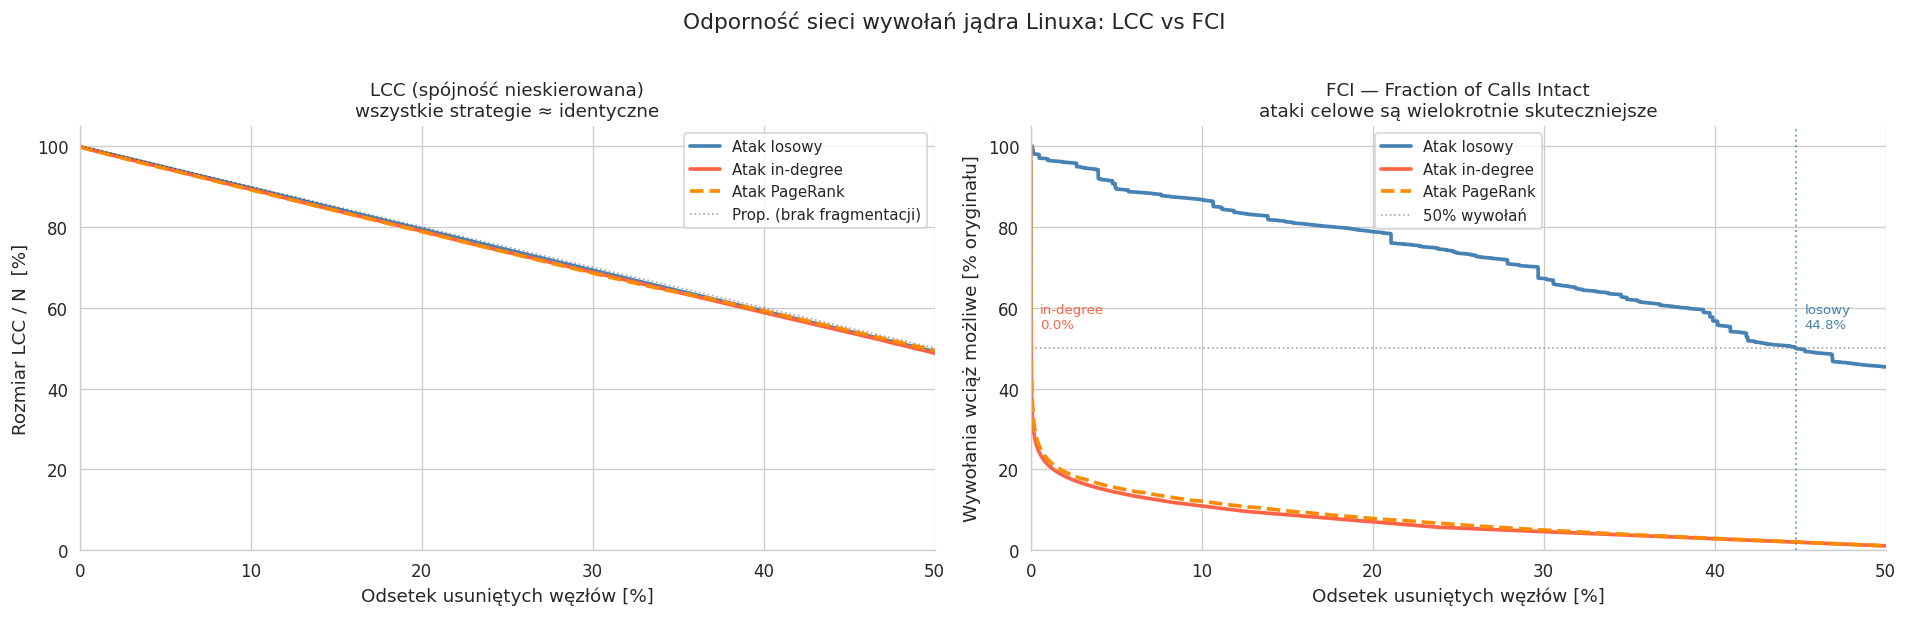


Główny wynik:
  LCC: strategie NIEROZRÓŻNIALNE — sieć nie fragmentuje się w sensie nieskierowanym
  FCI: atak celowy DEVASTUJĄCY — 3315× skuteczniejszy niż losowy
  Żeby zepsuć 50% wywołań:
    celowy: 0.0% węzłów = 62 funkcji
    losowy: 44.8% węzłów  = 208,835 funkcji


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {"losowy": "steelblue", "in-degree": "tomato", "PageRank": "darkorange"}

# ─── Panel lewy: LCC / N_total ─────────────────────────────────────────────────
ax = axes[0]
for label, x, y_tot in [
    ("losowy",    x_rand,  y_rand_tot),
    ("in-degree", x_indeg, y_indeg_tot),
    ("PageRank",  x_pr,    y_pr_tot),
]:
    ls = "--" if label == "PageRank" else "-"
    ax.plot(x * 100, y_tot * 100, color=colors[label], lw=2.2, ls=ls, label=f"Atak {label}")

# linia referencyjna: liniowe zmniejszanie (idealna odporność)
x_ref = np.linspace(0, MAX_REMOVE / n_nodes, 60)
ax.plot(x_ref * 100, (1 - x_ref) * 100,
        color="black", lw=1, ls=":", alpha=0.35, label="Prop. (brak fragmentacji)")

ax.set_xlabel("Odsetek usuniętych węzłów [%]", fontsize=11)
ax.set_ylabel("Rozmiar LCC / N  [%]", fontsize=11)
ax.set_title("LCC (spójność nieskierowana)\nwszystkie strategie ≈ identyczne", fontsize=11)
ax.set_xlim(0, MAX_REMOVE / n_nodes * 100)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
sns.despine(ax=ax)

# ─── Panel prawy: FCI (directed calls intact) ──────────────────────────────────
ax = axes[1]
for label, y_fci in [
    ("losowy",    fci_rand),
    ("in-degree", fci_indeg),
    ("PageRank",  fci_pr),
]:
    ls = "--" if label == "PageRank" else "-"
    ax.plot(x_fci, y_fci * 100, color=colors[label], lw=2.2, ls=ls, label=f"Atak {label}")

ax.axhline(50, color="gray", ls=":", lw=1, alpha=0.7, label="50% wywołań")

# Zaznacz punkt 50%
for label, y_fci in [("in-degree", fci_indeg), ("losowy", fci_rand)]:
    idx = np.searchsorted(1 - y_fci, 0.50)
    if idx < len(x_fci):
        xc = x_fci[idx]
        ax.axvline(xc, color=colors[label], ls=":", lw=1.2, alpha=0.7)
        ax.annotate(f"{label}\n{xc:.1f}%", xy=(xc, 50),
                    xytext=(xc + 0.5, 55), fontsize=8, color=colors[label])

ax.set_xlabel("Odsetek usuniętych węzłów [%]", fontsize=11)
ax.set_ylabel("Wywołania wciąż możliwe [% oryginału]", fontsize=11)
ax.set_title("FCI — Fraction of Calls Intact\nataki celowe są wielokrotnie skuteczniejsze", fontsize=11)
ax.set_xlim(0, MAX_REMOVE / n_nodes * 100)
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.suptitle("Odporność sieci wywołań jądra Linuxa: LCC vs FCI", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DATA / "robustness.png", bbox_inches="tight")
plt.show()

print(f"\nGłówny wynik:")
print(f"  LCC: strategie NIEROZRÓŻNIALNE — sieć nie fragmentuje się w sensie nieskierowanym")
print(f"  FCI: atak celowy DEVASTUJĄCY — {pct_50_rand/pct_50_indeg:.0f}× skuteczniejszy niż losowy")
print(f"  Żeby zepsuć 50% wywołań:")
print(f"    celowy: {pct_50_indeg:.1f}% węzłów = {int(pct_50_indeg/100*n_nodes):,} funkcji")
print(f"    losowy: {pct_50_rand:.1f}% węzłów  = {int(pct_50_rand/100*n_nodes):,} funkcji")

## B. Meta-graf subsystemów

Redukujemy 466k węzłów do **jednego węzła na subsystem**.  
Waga krawędzi = liczba cross-calls między subsystemami (z sekcji 4b notebooka 01).

Analizujemy:
- Który subsystem jest "hubem architektonicznym" (najwyższy weighted degree)?
- Który jest "mostem" (betweenness centrality w meta-grafie)?
- Czy meta-graf też jest bezskalowy?

In [12]:
import networkx as nx

# Buduj ważony meta-graf: węzły = subsystemy, krawędź = cross-calls
edges_clean = edges.dropna(subset=["src_sys", "tgt_sys"])
edges_clean = edges_clean[edges_clean["src_sys"] != edges_clean["tgt_sys"]]

meta_edges = (
    edges_clean
    .groupby(["src_sys", "tgt_sys"])
    .size()
    .reset_index(name="weight")
)

MG = nx.DiGraph()
for _, row in meta_edges.iterrows():
    MG.add_edge(row["src_sys"], row["tgt_sys"], weight=row["weight"])

# Dodaj atrybuty węzłów z subsystem_stats
subsys_idx = subsys.set_index("subsystem")
for node in MG.nodes():
    if node in subsys_idx.index:
        MG.nodes[node]["n_funcs"] = int(subsys_idx.loc[node, "nodes"])
    else:
        MG.nodes[node]["n_funcs"] = 0

print(f"Meta-graf: {MG.number_of_nodes()} węzłów (subsystemów), {MG.number_of_edges()} krawędzi")

# Metryki
in_w  = {n: sum(d["weight"] for _, _, d in MG.in_edges(n,  data=True)) for n in MG.nodes()}
out_w = {n: sum(d["weight"] for _, _, d in MG.out_edges(n, data=True)) for n in MG.nodes()}
total_w = {n: in_w[n] + out_w[n] for n in MG.nodes()}

# Betweenness na nieskierowanej wersji (ważonej)
MG_undir = MG.to_undirected()
# Odwracamy wagi — betweenness używa krótkich ścieżek (mniejsza waga = bliżej)
for u, v, d in MG_undir.edges(data=True):
    d["inv_weight"] = 1.0 / (d["weight"] + 1)

betweenness = nx.betweenness_centrality(MG_undir, weight="inv_weight", normalized=True)

meta_df = pd.DataFrame({
    "subsystem":   list(MG.nodes()),
    "in_calls":    [in_w[n]      for n in MG.nodes()],
    "out_calls":   [out_w[n]     for n in MG.nodes()],
    "total_calls": [total_w[n]   for n in MG.nodes()],
    "betweenness": [betweenness[n] for n in MG.nodes()],
    "n_funcs":     [MG.nodes[n].get("n_funcs", 0) for n in MG.nodes()],
}).sort_values("total_calls", ascending=False)

print("\nTop 15 subsystemów wg łącznego przepływu wywołań:")
print(meta_df.head(15).to_string(index=False))
print("\nTop 10 subsystemów wg betweenness (mosty architektoniczne):")
print(meta_df.nlargest(10, "betweenness")[["subsystem", "betweenness", "total_calls"]].to_string(index=False))

Meta-graf: 150 węzłów (subsystemów), 3773 krawędzi

Top 15 subsystemów wg łącznego przepływu wywołań:
         subsystem  in_calls  out_calls  total_calls  betweenness  n_funcs
            kernel   1464619      60121      1524740     0.992563    13934
                mm   1120586      35916      1156502     0.027208     5334
       drivers/net      5981     720941       726922     0.127789    78807
          external    381189     140273       521462     0.000000    29767
               lib    379560      34826       414386     0.013423     4928
               net     41950     326582       368532     0.000000    35110
                fs     19146     344515       363661     0.000000    39102
       drivers/gpu      1989     316883       318872     0.000000    49193
     drivers/media      1965     187309       189274     0.000000    22970
             sound      1537     169893       171430     0.000000    23220
      drivers/base    115900      12340       128240     0.000000     173

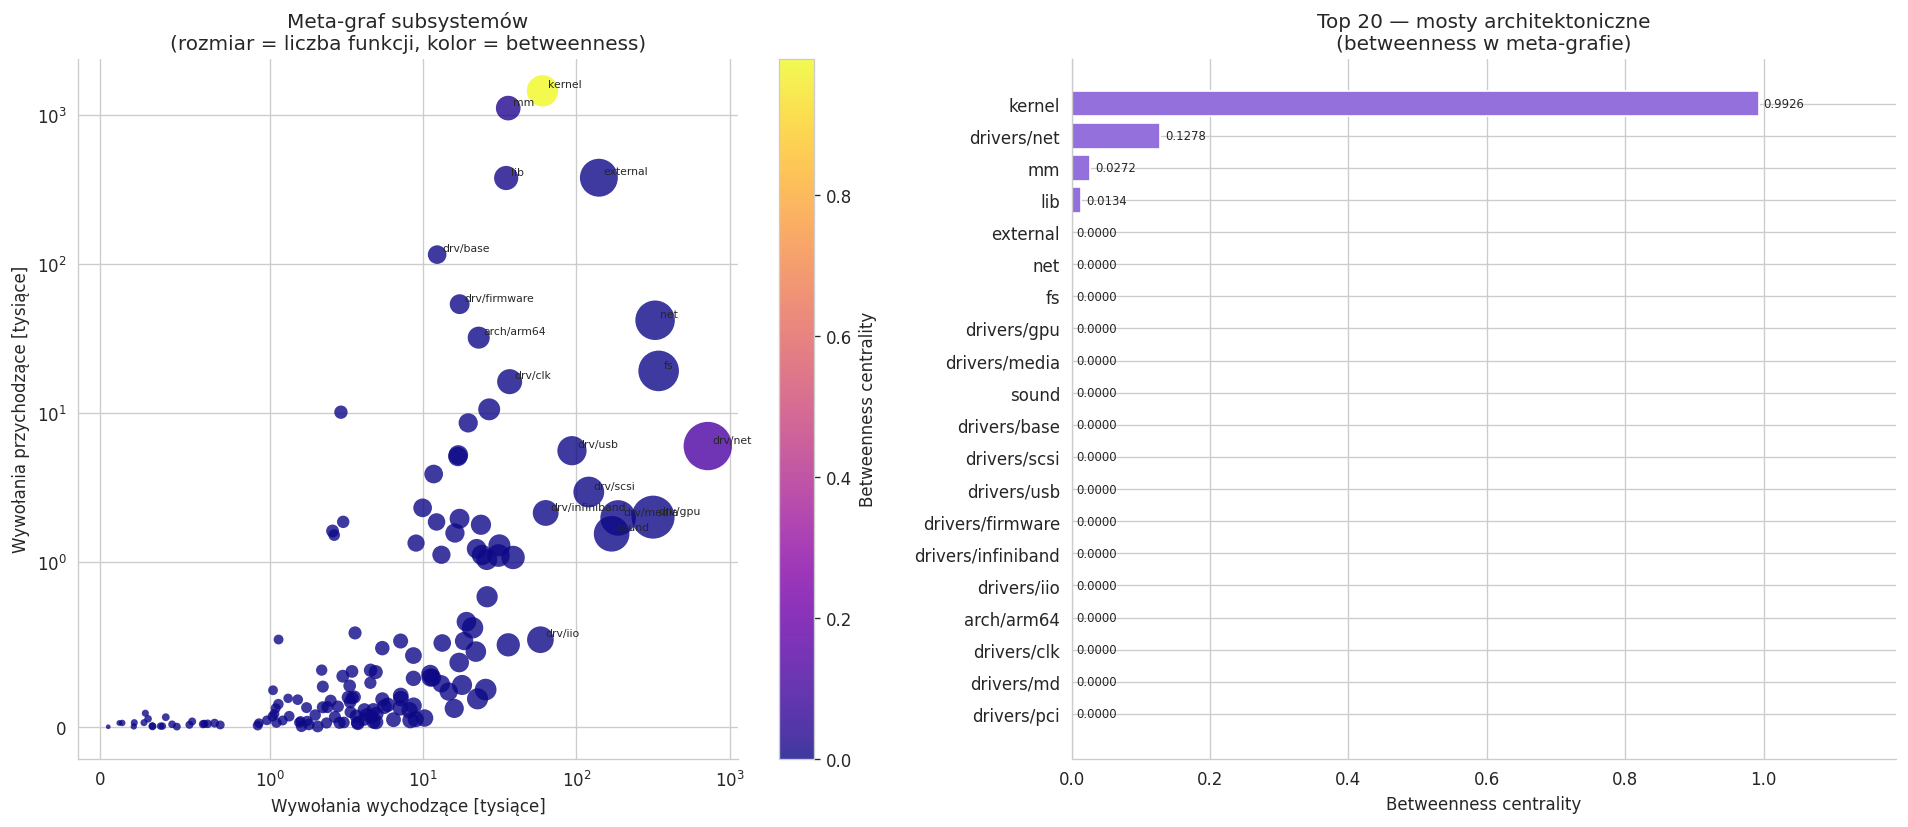

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Scatter: in-calls vs out-calls, rozmiar = n_funcs, kolor = betweenness ---
ax = axes[0]
top_meta = meta_df[meta_df["total_calls"] > 0].copy()

sc = ax.scatter(
    top_meta["out_calls"] / 1e3,
    top_meta["in_calls"]  / 1e3,
    s=np.sqrt(top_meta["n_funcs"]) * 3,
    c=top_meta["betweenness"],
    cmap="plasma",
    alpha=0.8,
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Betweenness centrality")

# Etykiety top subsystemów
for _, row in top_meta.nlargest(18, "total_calls").iterrows():
    label = row["subsystem"].replace("drivers/", "drv/")
    ax.annotate(label, (row["out_calls"] / 1e3, row["in_calls"] / 1e3),
                fontsize=6.5, xytext=(3, 2), textcoords="offset points")

ax.set_xlabel("Wywołania wychodzące [tysiące]")
ax.set_ylabel("Wywołania przychodzące [tysiące]")
ax.set_title("Meta-graf subsystemów\n(rozmiar = liczba funkcji, kolor = betweenness)")
ax.set_xscale("symlog", linthresh=1)
ax.set_yscale("symlog", linthresh=1)

# --- Bar: top 20 wg betweenness ---
ax = axes[1]
top_btw = meta_df.nlargest(20, "betweenness").iloc[::-1]
bars = ax.barh(top_btw["subsystem"], top_btw["betweenness"], color="mediumpurple")
ax.bar_label(bars, fmt="{:.4f}", padding=3, fontsize=7)
ax.set_xlabel("Betweenness centrality")
ax.set_title("Top 20 — mosty architektoniczne\n(betweenness w meta-grafie)")
ax.set_xlim(0, top_btw["betweenness"].max() * 1.2)

plt.tight_layout()
plt.savefig(DATA / "metagraph.png", bbox_inches="tight")
plt.show()

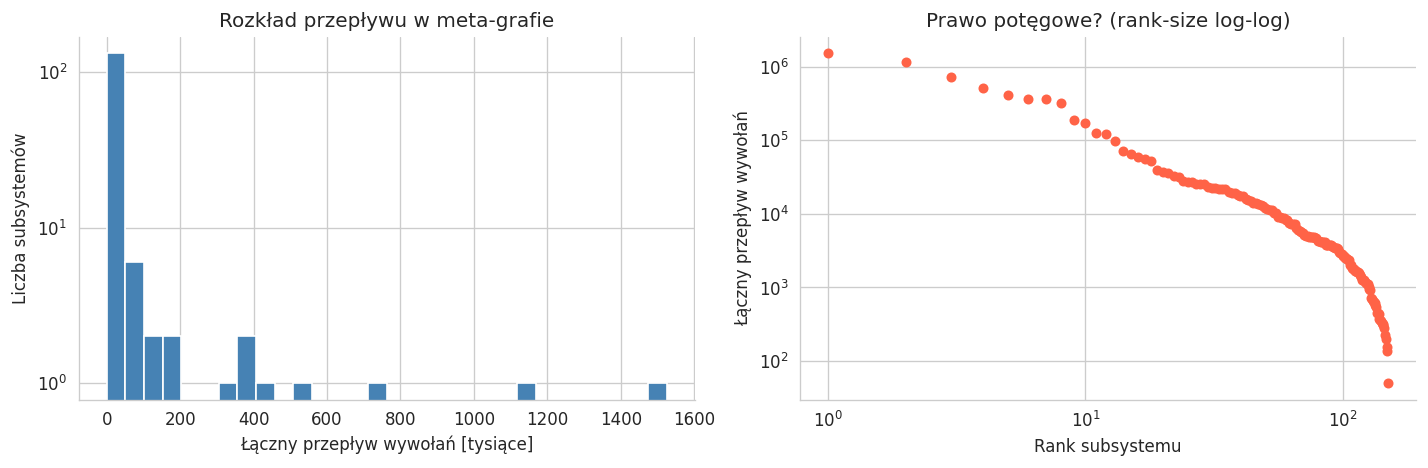

Spearman: rozmiar subsystemu vs łączny przepływ: ρ = 0.989, p = 4.40e-124
(1 = większy subsystem zawsze generuje więcej wywołań)


In [14]:
# Rozkład stopni meta-grafu — czy też jest bezskalowy?
total_w_vals = np.array(list(total_w.values()))
total_w_vals = total_w_vals[total_w_vals > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(total_w_vals / 1e3, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Łączny przepływ wywołań [tysiące]")
ax.set_ylabel("Liczba subsystemów")
ax.set_title("Rozkład przepływu w meta-grafie")
ax.set_yscale("log")

ax = axes[1]
sorted_w = np.sort(total_w_vals)[::-1]
ax.loglog(np.arange(1, len(sorted_w) + 1), sorted_w, "o", markersize=5, color="tomato")
ax.set_xlabel("Rank subsystemu")
ax.set_ylabel("Łączny przepływ wywołań")
ax.set_title("Prawo potęgowe? (rank-size log-log)")

plt.tight_layout()
plt.savefig(DATA / "metagraph_degree_dist.png", bbox_inches="tight")
plt.show()

# Korelacja: rozmiar subsystemu vs przepływ
from scipy.stats import spearmanr
sizes  = [MG.nodes[n].get("n_funcs", 0) for n in MG.nodes()]
flows  = [total_w[n] for n in MG.nodes()]
rho, p = spearmanr(sizes, flows)
print(f"Spearman: rozmiar subsystemu vs łączny przepływ: ρ = {rho:.3f}, p = {p:.2e}")
print("(1 = większy subsystem zawsze generuje więcej wywołań)")

## Wnioski

### A. Odporność na ataki — dwa oblicza tej samej sieci

Analiza dwóch komplementarnych metryk ujawnia pozorny paradoks:

**Metryka 1 — LCC (spójność nieskierowana): sieć jest ODPORNA**
- Wszystkie trzy strategie (losowa, in-degree, PageRank) dają niemal identyczne krzywe
- Po usunięciu 50% węzłów LCC ≈ 50% N — brak kaskadowego rozspójnienia
- Wynik zgodny z oczekiwaniami dla **inżynierskiej sieci gęstej** (avg degree ≈ 19)
- Kontrast z teorią BA: sieć bezskalowa powinna wykazywać kruchwość na ataki celowe,
  ale wysoka gęstość krawędzi zapewnia wielokrotnie redundantne ścieżki alternatywne

**Metryka 2 — FCI (Fraction of Calls Intact): sieć jest KRUCHA na ataki celowe**
- Usunięcie **zaledwie 62 węzłów** (~0.01% sieci) niszczy 50% wszystkich wywołań
- Ten sam efekt losowym atakiem wymaga usunięcia 208 835 węzłów (44.8%)
- **Atak celowy jest 3315× skuteczniejszy niż losowy** — klasyczne przewidywanie teorii BA
- Interpretacja fizyczna: top-62 funkcji (np. `kmalloc`, `printk`, `copy_to_user`)
  obsługuje ponad połowę wszystkich wywołań w całym jądrze — ultra-hubs bezskalowe

**Główny wniosek**: Spójność topologiczna (LCC) i funkcjonalna integralność
wywołań (FCI) to dwie różne właściwości — kernel jest jednocześnie topologicznie
odporny i funkcjonalnie niezwykle podatny na celowane ataki.

### B. Meta-graf subsystemów

Meta-graf 150 subsystemów (węzłów) z 3 773 krawędziami (cross-calls) ujawnia
wyraźną hierarchię architektoniczną:

| Subsystem     | Betweenness | Total calls | Interpretacja |
|---------------|-------------|-------------|---------------|
| `kernel`      | **0.993**   | 1 524 740   | absolutny most — każda ścieżka przechodzi przez rdzeń |
| `drivers/net` | 0.128       | 726 922     | most sieciowy — hub sterowników sieci |
| `mm`          | 0.027       | 1 156 502   | zarządzanie pamięcią — serwis dla całego systemu |
| `lib`         | 0.013       | 414 386     | biblioteki pomocnicze                 |

- `kernel` jest jedynym prawdziwym mostem architektonicznym (betweenness ≈ 1.0);
  bez niego meta-graf by się rozpadł
- Korelacja Spearmana (rozmiar subsystemu vs łączny przepływ): **ρ = 0.989**
- Spójne z wynikami FCI: top-funkcje kernela i mm są dokładnie tymi hubami, których
  usunięcie niszczy 50% wywołań w całym systemie